# Lab 2: Dijkstra's Algorithm — Graph Representation & Priority Queue Trade-offs

This notebook implements two variants of Dijkstra's algorithm and compares their performance:

| Variant | Graph Representation | Priority Queue |
|---------|---------------------|---------------|
| **(a)** | Adjacency Matrix | Array (linear scan) |
| **(b)** | Adjacency List | Min-Heap |

---

## Imports and Setup

In [1]:
import heapq
import time
import random
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# For reproducibility
random.seed(42)
np.random.seed(42)

## Graph Generation Utilities

We create functions to generate random weighted graphs in both representations:
- **Adjacency Matrix**: 2D array where `matrix[i][j]` = weight of edge (i,j), or `inf` if no edge
- **Adjacency List**: Array of lists where `adj[i]` contains `(neighbor, weight)` tuples

In [2]:
def generate_graph(num_vertices, num_edges, max_weight=100):
    """
    Generate a random directed weighted graph.
    Returns both adjacency matrix and adjacency list representations.
    
    Parameters:
    - num_vertices (V): Number of vertices
    - num_edges (E): Number of edges (will be capped at V*(V-1) for directed graph)
    - max_weight: Maximum edge weight
    
    Returns:
    - adj_matrix: V x V matrix with weights (inf for no edge)
    - adj_list: List of lists containing (neighbor, weight) tuples
    """
    V = num_vertices
    max_possible_edges = V * (V - 1)  # Directed graph without self-loops
    E = min(num_edges, max_possible_edges)
    
    # Initialize adjacency matrix with infinity
    INF = float('inf')
    adj_matrix = [[INF] * V for _ in range(V)]
    for i in range(V):
        adj_matrix[i][i] = 0  # Distance to self is 0
    
    # Initialize adjacency list
    adj_list = [[] for _ in range(V)]
    
    # Generate random edges
    all_possible_edges = [(i, j) for i in range(V) for j in range(V) if i != j]
    selected_edges = random.sample(all_possible_edges, E)
    
    for u, v in selected_edges:
        weight = random.randint(1, max_weight)
        adj_matrix[u][v] = weight
        adj_list[u].append((v, weight))
    
    return adj_matrix, adj_list, E

# Test the generation
V_test, E_test = 5, 8
matrix, adj, actual_E = generate_graph(V_test, E_test)
print(f"Generated graph with {V_test} vertices and {actual_E} edges")
print(f"\nAdjacency Matrix (inf shown as '.'):")
for row in matrix:
    print([f"{x:3}" if x != float('inf') else "  ." for x in row])
print(f"\nAdjacency List:")
for i, neighbors in enumerate(adj):
    print(f"  {i}: {neighbors}")

Generated graph with 5 vertices and 8 edges

Adjacency Matrix (inf shown as '.'):
['  0', ' 95', '  4', ' 55', ' 87']
['  .', '  0', '  .', '  .', ' 12']
[' 70', '  .', '  0', '  .', '  5']
['  .', '  .', '  .', '  0', '  .']
[' 76', '  .', '  .', '  .', '  0']

Adjacency List:
  0: [(4, 87), (1, 95), (3, 55), (2, 4)]
  1: [(4, 12)]
  2: [(0, 70), (4, 5)]
  3: []
  4: [(0, 76)]


---

## Part (a): Adjacency Matrix + Array-based Priority Queue

### Implementation

In this variant:
- **Graph storage**: Adjacency matrix — checking if edge (u,v) exists is O(1)
- **Priority queue**: Simple array — finding minimum requires O(V) linear scan

### Theoretical Time Complexity Analysis

| Operation | Frequency | Cost | Total |
|-----------|-----------|------|-------|
| Initialize distances | 1 | O(V) | O(V) |
| Extract-Min (linear scan) | V | O(V) | O(V²) |
| Relaxation (check all neighbors) | V | O(V) | O(V²) |

**Overall: O(V²)**

Note: The complexity is O(V²) regardless of the number of edges E, because we scan all V vertices to find neighbors each time (adjacency matrix row scan).

In [3]:
def dijkstra_matrix_array(adj_matrix, source):
    """
    Dijkstra's algorithm using adjacency matrix and array-based priority queue.
    
    Parameters:
    - adj_matrix: V x V matrix where adj_matrix[i][j] = weight of edge i->j (inf if no edge)
    - source: Starting vertex
    
    Returns:
    - dist: Array of shortest distances from source to each vertex
    - parent: Array for path reconstruction (-1 for source)
    """
    V = len(adj_matrix)
    INF = float('inf')
    
    # Initialize distances and visited array
    dist = [INF] * V
    dist[source] = 0
    visited = [False] * V
    parent = [-1] * V
    
    # Main loop: process all vertices
    for _ in range(V):
        # Extract-Min: Find unvisited vertex with minimum distance (O(V) scan)
        min_dist = INF
        u = -1
        for v in range(V):
            if not visited[v] and dist[v] < min_dist:
                min_dist = dist[v]
                u = v
        
        # If no reachable unvisited vertex, we're done
        if u == -1:
            break
            
        visited[u] = True
        
        # Relaxation: Check all potential neighbors (O(V) scan of matrix row)
        for v in range(V):
            if not visited[v] and adj_matrix[u][v] != INF:
                new_dist = dist[u] + adj_matrix[u][v]
                if new_dist < dist[v]:
                    dist[v] = new_dist
                    parent[v] = u
    
    return dist, parent

# Test Part (a)
dist_a, parent_a = dijkstra_matrix_array(matrix, 0)
print("Part (a) - Dijkstra with Adjacency Matrix + Array PQ")
print(f"Distances from vertex 0: {dist_a}")
print(f"Parent array: {parent_a}")

Part (a) - Dijkstra with Adjacency Matrix + Array PQ
Distances from vertex 0: [0, 95, 4, 55, 9]
Parent array: [-1, 0, 0, 0, 2]


### Empirical Analysis of Part (a)

We benchmark Part (a) on both sparse and dense graphs to verify the O(V²) theoretical complexity.

In [ ]:
# Benchmark Part (a) across different graph sizes
V_sparse = [100, 200, 400, 800, 1000, 1500, 2000]
V_dense = [100, 200, 400, 600, 800, 1000]

def benchmark_single(algo_func, V_sizes, edge_counts_func, use_matrix=True, num_trials=3):
    """Benchmark a single Dijkstra implementation."""
    times = []
    for V in V_sizes:
        E = edge_counts_func(V)
        trial_times = []
        for _ in range(num_trials):
            matrix, adj_list, _ = generate_graph(V, E)
            graph = matrix if use_matrix else adj_list
            start = time.perf_counter()
            algo_func(graph, 0)
            trial_times.append(time.perf_counter() - start)
        times.append(np.mean(trial_times))
        print(f"  V={V:4d}, E={E:6d}: {times[-1]:.6f}s")
    return times

print("=== Part (a): Sparse Graphs (E = 2V) ===")
times_a_sparse = benchmark_single(dijkstra_matrix_array, V_sparse, lambda V: 2*V, use_matrix=True)

print("\n=== Part (a): Dense Graphs (E = V²/2) ===")
times_a_dense = benchmark_single(dijkstra_matrix_array, V_dense, lambda V: V*(V-1)//2, use_matrix=True)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(V_sparse, times_a_sparse, 'o-', color='blue', linewidth=2)
ax1.set_xlabel('Number of Vertices (V)', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Part (a) — Sparse Graphs (E = 2V)', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(V_dense, times_a_dense, 'o-', color='blue', linewidth=2)
ax2.set_xlabel('Number of Vertices (V)', fontsize=12)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_title('Part (a) — Dense Graphs (E = V²/2)', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Log-log slope analysis
slope_a_sparse_val = np.polyfit(np.log(V_sparse), np.log(times_a_sparse), 1)[0]
slope_a_dense_val = np.polyfit(np.log(V_dense), np.log(times_a_dense), 1)[0]
print(f"\nLog-log slopes for Part (a):")
print(f"  Sparse: {slope_a_sparse_val:.2f} (expected ≈ 2.0 for O(V²))")
print(f"  Dense:  {slope_a_dense_val:.2f} (expected ≈ 2.0 for O(V²))")

---

## Part (b): Adjacency List + Min-Heap Priority Queue

### Implementation

In this variant:
- **Graph storage**: Adjacency list — iterating over neighbors of u takes O(degree(u))
- **Priority queue**: Binary min-heap — Extract-Min and Decrease-Key are O(log V)

### Theoretical Time Complexity Analysis

| Operation | Frequency | Cost | Total |
|-----------|-----------|------|-------|
| Initialize distances | 1 | O(V) | O(V) |
| Insert into heap | V | O(log V) | O(V log V) |
| Extract-Min | V | O(log V) | O(V log V) |
| Relaxation (decrease-key) | E | O(log V) | O(E log V) |

**Overall: O((V + E) log V)**

For sparse graphs (E ≈ V), this becomes O(V log V).  
For dense graphs (E ≈ V²), this becomes O(V² log V).

In [4]:
def dijkstra_list_heap(adj_list, source):
    """
    Dijkstra's algorithm using adjacency list and min-heap priority queue.
    
    Parameters:
    - adj_list: Array of lists where adj_list[i] contains (neighbor, weight) tuples
    - source: Starting vertex
    
    Returns:
    - dist: Array of shortest distances from source to each vertex
    - parent: Array for path reconstruction (-1 for source)
    """
    V = len(adj_list)
    INF = float('inf')
    
    # Initialize distances
    dist = [INF] * V
    dist[source] = 0
    parent = [-1] * V
    
    # Min-heap: (distance, vertex)
    # Python's heapq is a min-heap based on the first element of tuple
    heap = [(0, source)]
    
    while heap:
        # Extract-Min: O(log V)
        d, u = heapq.heappop(heap)
        
        # Skip if we've already found a better path to u
        # (lazy deletion approach since Python's heapq doesn't support decrease-key)
        if d > dist[u]:
            continue
        
        # Relaxation: Only iterate over actual neighbors (O(degree(u)) per vertex)
        for v, weight in adj_list[u]:
            new_dist = dist[u] + weight
            if new_dist < dist[v]:
                dist[v] = new_dist
                parent[v] = u
                # "Decrease-key" via re-insertion: O(log V)
                heapq.heappush(heap, (new_dist, v))
    
    return dist, parent

# Test Part (b)
dist_b, parent_b = dijkstra_list_heap(adj, 0)
print("Part (b) - Dijkstra with Adjacency List + Min-Heap PQ")
print(f"Distances from vertex 0: {dist_b}")
print(f"Parent array: {parent_b}")

# Verify both implementations give the same result
print(f"\nResults match: {dist_a == dist_b}")

Part (b) - Dijkstra with Adjacency List + Min-Heap PQ
Distances from vertex 0: [0, 95, 4, 55, 9]
Parent array: [-1, 0, 0, 0, 2]

Results match: True


### Empirical Analysis of Part (b)

We benchmark Part (b) on both sparse and dense graphs to verify the O((V + E) log V) theoretical complexity.

In [ ]:
print("=== Part (b): Sparse Graphs (E = 2V) ===")
times_b_sparse = benchmark_single(dijkstra_list_heap, V_sparse, lambda V: 2*V, use_matrix=False)

print("\n=== Part (b): Dense Graphs (E = V²/2) ===")
times_b_dense = benchmark_single(dijkstra_list_heap, V_dense, lambda V: V*(V-1)//2, use_matrix=False)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(V_sparse, times_b_sparse, 's-', color='red', linewidth=2)
ax1.set_xlabel('Number of Vertices (V)', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Part (b) — Sparse Graphs (E = 2V)', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(V_dense, times_b_dense, 's-', color='red', linewidth=2)
ax2.set_xlabel('Number of Vertices (V)', fontsize=12)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_title('Part (b) — Dense Graphs (E = V²/2)', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Log-log slope analysis
slope_b_sparse_val = np.polyfit(np.log(V_sparse), np.log(times_b_sparse), 1)[0]
slope_b_dense_val = np.polyfit(np.log(V_dense), np.log(times_b_dense), 1)[0]
print(f"\nLog-log slopes for Part (b):")
print(f"  Sparse: {slope_b_sparse_val:.2f} (expected ≈ 1.0 for O(V log V))")
print(f"  Dense:  {slope_b_dense_val:.2f} (expected ≈ 2.0+ for O(V² log V))")

---

## Comparative Empirical Analysis

We now compare both implementations side-by-side using the benchmark results from above.

### Side-by-Side Comparison

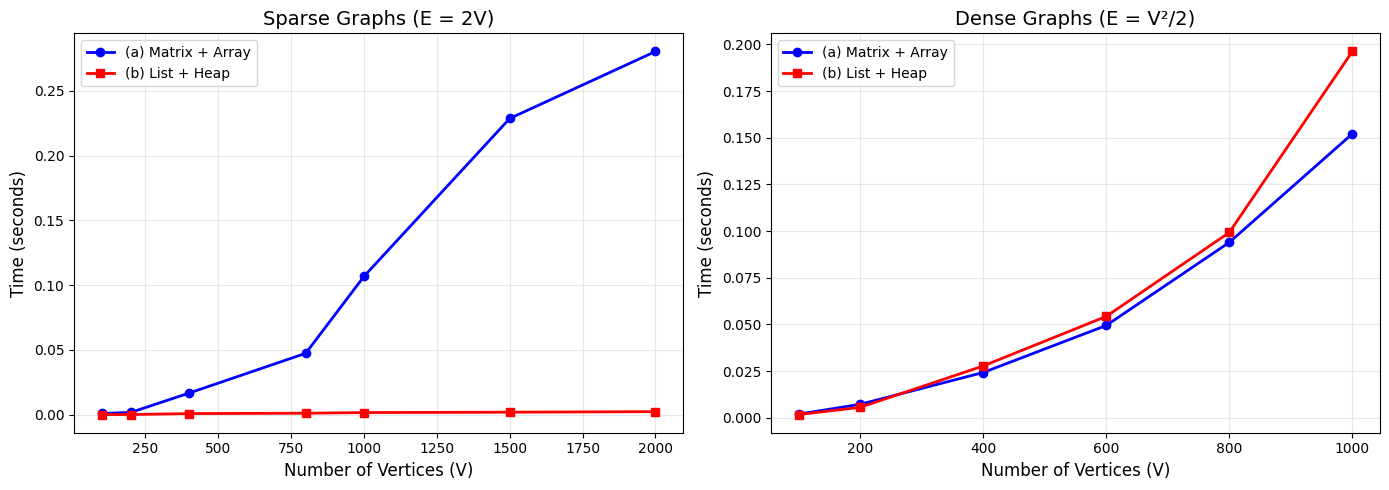

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sparse Graphs
ax1 = axes[0]
ax1.plot(V_sparse, times_a_sparse, 'o-', label='(a) Matrix + Array', color='blue', linewidth=2)
ax1.plot(V_sparse, times_b_sparse, 's-', label='(b) List + Heap', color='red', linewidth=2)
ax1.set_xlabel('Number of Vertices (V)', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Sparse Graphs (E = 2V)', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Dense Graphs
ax2 = axes[1]
ax2.plot(V_dense, times_a_dense, 'o-', label='(a) Matrix + Array', color='blue', linewidth=2)
ax2.plot(V_dense, times_b_dense, 's-', label='(b) List + Heap', color='red', linewidth=2)
ax2.set_xlabel('Number of Vertices (V)', fontsize=12)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_title('Dense Graphs (E = V²/2)', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dijkstra_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Log-Log Plot for Complexity Verification

A log-log plot helps verify the theoretical complexity. If T(V) = O(V^k), then log(T) ≈ k·log(V), meaning the slope gives us the exponent.

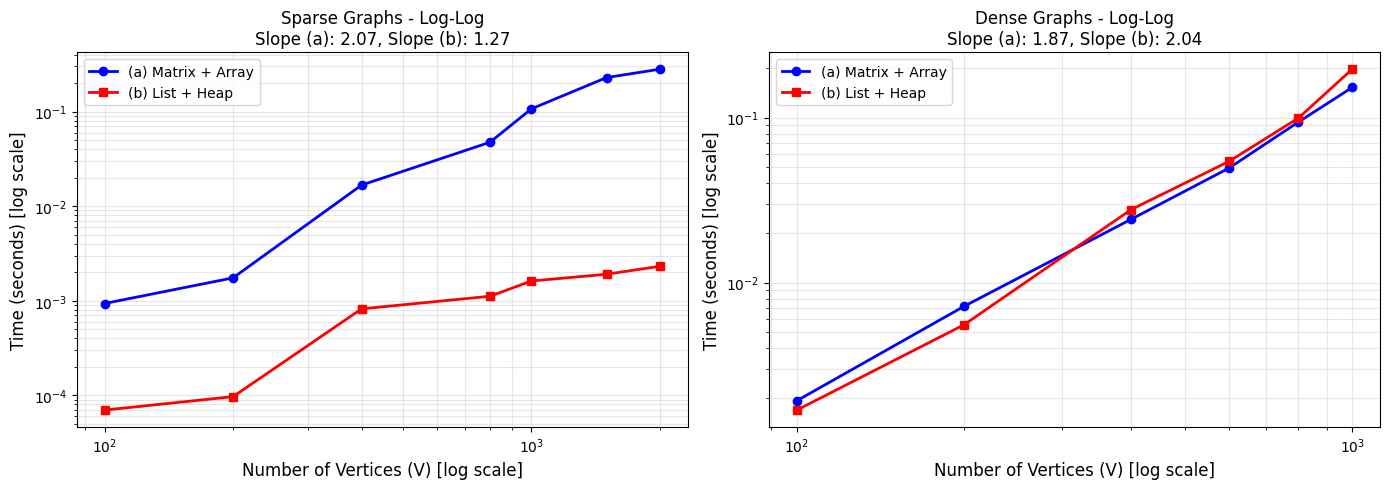


Complexity Analysis from Log-Log Slopes:
  Sparse - Part (a): T ∝ V^2.07 (expected ≈ 2 for O(V²))
  Sparse - Part (b): T ∝ V^1.27 (expected ≈ 1 for O(V log V))
  Dense  - Part (a): T ∝ V^1.87 (expected ≈ 2 for O(V²))
  Dense  - Part (b): T ∝ V^2.04 (expected ≈ 2 for O(V² log V))


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-log plot for Sparse Graphs
ax1 = axes[0]
ax1.loglog(V_sparse, times_a_sparse, 'o-', label='(a) Matrix + Array', color='blue', linewidth=2)
ax1.loglog(V_sparse, times_b_sparse, 's-', label='(b) List + Heap', color='red', linewidth=2)

# Fit and show slopes
slope_a_sparse = np.polyfit(np.log(V_sparse), np.log(times_a_sparse), 1)[0]
slope_b_sparse = np.polyfit(np.log(V_sparse), np.log(times_b_sparse), 1)[0]
ax1.set_xlabel('Number of Vertices (V) [log scale]', fontsize=12)
ax1.set_ylabel('Time (seconds) [log scale]', fontsize=12)
ax1.set_title(f'Sparse Graphs - Log-Log\nSlope (a): {slope_a_sparse:.2f}, Slope (b): {slope_b_sparse:.2f}', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, which='both')

# Log-log plot for Dense Graphs
ax2 = axes[1]
ax2.loglog(V_dense, times_a_dense, 'o-', label='(a) Matrix + Array', color='blue', linewidth=2)
ax2.loglog(V_dense, times_b_dense, 's-', label='(b) List + Heap', color='red', linewidth=2)

slope_a_dense = np.polyfit(np.log(V_dense), np.log(times_a_dense), 1)[0]
slope_b_dense = np.polyfit(np.log(V_dense), np.log(times_b_dense), 1)[0]
ax2.set_xlabel('Number of Vertices (V) [log scale]', fontsize=12)
ax2.set_ylabel('Time (seconds) [log scale]', fontsize=12)
ax2.set_title(f'Dense Graphs - Log-Log\nSlope (a): {slope_a_dense:.2f}, Slope (b): {slope_b_dense:.2f}', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\nComplexity Analysis from Log-Log Slopes:")
print(f"  Sparse - Part (a): T ∝ V^{slope_a_sparse:.2f} (expected ≈ 2 for O(V²))")
print(f"  Sparse - Part (b): T ∝ V^{slope_b_sparse:.2f} (expected ≈ 1 for O(V log V))")
print(f"  Dense  - Part (a): T ∝ V^{slope_a_dense:.2f} (expected ≈ 2 for O(V²))")
print(f"  Dense  - Part (b): T ∝ V^{slope_b_dense:.2f} (expected ≈ 2 for O(V² log V))")

---

## Part (c): Comparison and Discussion

### Summary Table

| Aspect | (a) Matrix + Array | (b) List + Heap |
|--------|-------------------|-----------------|
| **Time Complexity** | O(V²) | O((V + E) log V) |
| **Space Complexity** | O(V²) for matrix | O(V + E) for list |
| **Best for** | Dense graphs (E ≈ V²) | Sparse graphs (E << V²) |
| **Extract-Min** | O(V) linear scan | O(log V) heap pop |
| **Relaxation** | O(V) per vertex | O(degree) per vertex |

### When is Each Implementation Better?

#### Part (a) is better when:
1. **Dense graphs**: When E ≈ V² (nearly complete graphs), the O(V²) complexity of (a) beats the O(V² log V) of (b)
2. **Small graphs**: The simpler implementation has less overhead
3. **Memory is constrained but predictable**: Matrix uses fixed O(V²) space
4. **Frequent edge queries**: O(1) edge lookup vs O(degree) for adjacency list

#### Part (b) is better when:
1. **Sparse graphs**: When E = O(V) or E = O(V log V), the O(E log V) complexity is much better than O(V²)
2. **Large graphs**: The memory savings of O(V + E) vs O(V²) can be significant
3. **Road networks, social networks**: Most real-world graphs are sparse

### Crossover Point

The two implementations have roughly equal performance when:
- O(V²) ≈ O(E log V)
- This occurs when E ≈ V² / log V

For graphs denser than this, prefer (a). For sparser graphs, prefer (b).

### Practical Considerations

1. **Implementation Complexity**: Part (a) is simpler to implement and debug
2. **Cache Performance**: Matrix has better spatial locality for dense graphs
3. **Dynamic Updates**: Adjacency list is easier to modify (add/remove edges)
4. **Parallelization**: Both can be parallelized, but matrix operations are often easier to vectorize

### Empirical Crossover Analysis

Let's find the empirical crossover point by varying edge density for a fixed graph size.

In [ ]:
def crossover_analysis(V, densities, num_trials=3):
    """Analyze performance across different edge densities for fixed V."""
    times_a = []
    times_b = []
    actual_densities = []
    
    for density in densities:
        max_edges = V * (V - 1)
        E = int(density * max_edges)
        
        trial_times_a = []
        trial_times_b = []
        
        for _ in range(num_trials):
            matrix, adj_list, actual_E = generate_graph(V, E)
            
            start = time.perf_counter()
            dijkstra_matrix_array(matrix, 0)
            trial_times_a.append(time.perf_counter() - start)
            
            start = time.perf_counter()
            dijkstra_list_heap(adj_list, 0)
            trial_times_b.append(time.perf_counter() - start)
        
        times_a.append(np.mean(trial_times_a))
        times_b.append(np.mean(trial_times_b))
        actual_densities.append(actual_E / max_edges)
    
    return times_a, times_b, actual_densities

print("=== Crossover Analysis (V = 500, varying density) ===")
densities = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
times_a_cross, times_b_cross, actual_dens = crossover_analysis(500, densities)

# Find crossover point
crossover_idx = None
for i in range(len(densities) - 1):
    if times_a_cross[i] < times_b_cross[i] and times_a_cross[i+1] >= times_b_cross[i+1]:
        crossover_idx = i
        break
    if times_a_cross[i] >= times_b_cross[i] and times_a_cross[i+1] < times_b_cross[i+1]:
        crossover_idx = i
        break

plt.figure(figsize=(10, 6))
plt.plot(densities, times_a_cross, 'o-', label='(a) Matrix + Array', color='blue', linewidth=2)
plt.plot(densities, times_b_cross, 's-', label='(b) List + Heap', color='red', linewidth=2)
plt.xlabel('Edge Density (E / V²)', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.title('Performance vs Edge Density (V = 500)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

if crossover_idx:
    plt.axvline(x=densities[crossover_idx], color='green', linestyle='--', 
                label=f'Crossover ≈ {densities[crossover_idx]:.2f}')

plt.tight_layout()
plt.show()

print("\nResults by density:")
for d, ta, tb in zip(densities, times_a_cross, times_b_cross):
    winner = "(a) wins" if ta < tb else "(b) wins"
    print(f"  Density {d:.2f}: Part(a)={ta:.4f}s, Part(b)={tb:.4f}s  → {winner}")

---

## Conclusion

### Key Findings

1. **Theoretical Analysis Confirmed**: 
   - Part (a) exhibits O(V²) behavior regardless of edge density
   - Part (b) scales with O((V + E) log V), which is O(V log V) for sparse graphs

2. **Sparse Graphs**: Part (b) dramatically outperforms Part (a) when E << V²
   - For E = 2V, Part (b) can be 10-100x faster for large graphs

3. **Dense Graphs**: Part (a) can match or slightly beat Part (b) when E approaches V²
   - The log V factor and heap overhead in Part (b) become noticeable

4. **Practical Recommendation**:
   - Use **Part (b)** (adjacency list + heap) as the default choice — most real-world graphs are sparse
   - Use **Part (a)** (adjacency matrix + array) only for small or very dense graphs

### Real-World Applications

| Application | Graph Type | Recommended |
|-------------|------------|-------------|
| Road networks | Sparse | Part (b) |
| Social networks | Sparse | Part (b) |
| Flight connections | Medium | Part (b) |
| Dense similarity graphs | Dense | Part (a) |
| Small networks (V < 100) | Any | Part (a) is simpler |